In [1]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.7 MB/s eta 0:00:00


In [2]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
query = "select * from mall_customer_db"

In [4]:
con = snowflake.connector.connect(
    user = "Alaguraja",
    password = "Alagurajakannan@787",
    account = "DXMKEOQ-ON75318",
    database = "mall_customer",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [5]:
df= pd.read_sql(query, con)

/tmp/ipykernel_1919/431579650.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query, con)


In [6]:
df

,CUSTOMERID,GENRE,AGE,ANNUAL_INCOME,SPENDING_SCORE
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CUSTOMERID      200 non-null    int64 
 1   GENRE           200 non-null    object
 2   AGE             200 non-null    int64 
 3   ANNUAL_INCOME   200 non-null    int64 
 4   SPENDING_SCORE  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.isnull().sum()

,0
CUSTOMERID,0
GENRE,0
AGE,0
ANNUAL_INCOME,0
SPENDING_SCORE,0


<Axes: xlabel='ANNUAL_INCOME', ylabel='SPENDING_SCORE'>

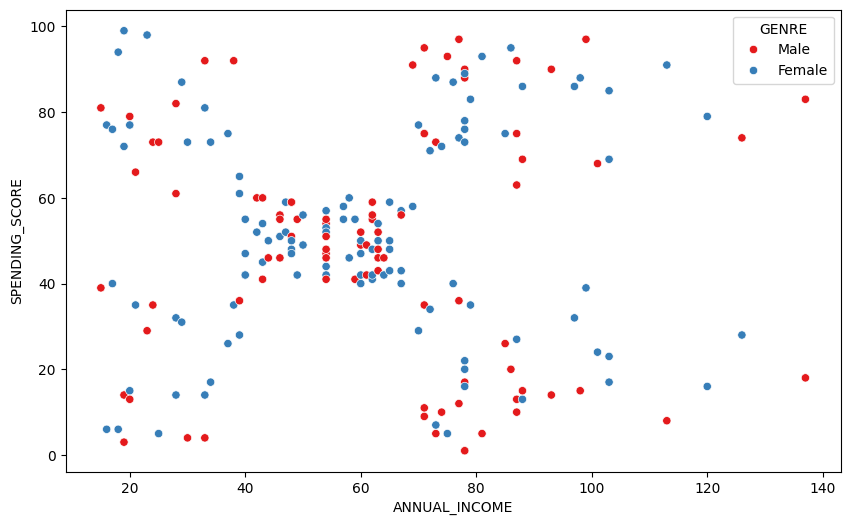

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='ANNUAL_INCOME',
    y='SPENDING_SCORE',
    hue = "GENRE",
    palette = "Set1"
)

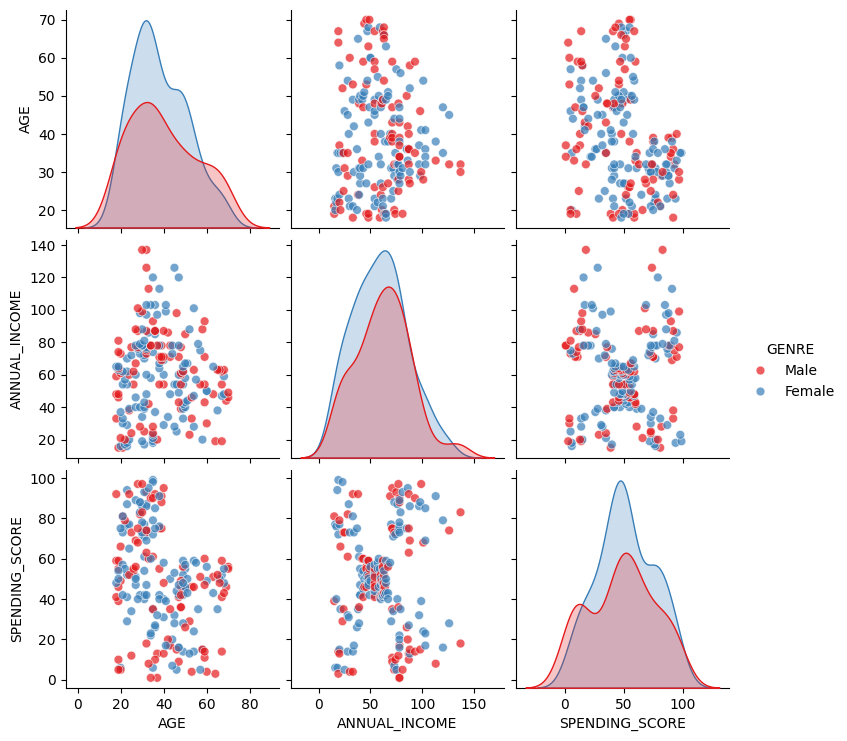

In [10]:
pair_plot = sns.pairplot(
    data=df.drop(columns=['CUSTOMERID']),
    hue='GENRE',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40}
)


In [11]:
q = df.iloc[:,3:].values
q

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [12]:
cd = q.copy()

In [13]:
from sklearn.cluster import DBSCAN
for i in range(1,11):
  for k in range(1,6):
    db = DBSCAN(eps=i,min_samples = k, metric = "euclidean")
    model = db.fit(cd)
    label = model.labels_
    min_count = 0
    count = 0
    for j in range(len(label)):
      if label[j] == -1:
        count += 1
    print(f"minimum number of -1 at {i}th iteration of eps and {k}th iteration of min_samples:", count)


minimum number of -1 at 1th iteration of eps and 1th iteration of min_samples: 0
minimum number of -1 at 1th iteration of eps and 2th iteration of min_samples: 149
minimum number of -1 at 1th iteration of eps and 3th iteration of min_samples: 179
minimum number of -1 at 1th iteration of eps and 4th iteration of min_samples: 200
minimum number of -1 at 1th iteration of eps and 5th iteration of min_samples: 200
minimum number of -1 at 2th iteration of eps and 1th iteration of min_samples: 0
minimum number of -1 at 2th iteration of eps and 2th iteration of min_samples: 94
minimum number of -1 at 2th iteration of eps and 3th iteration of min_samples: 138
minimum number of -1 at 2th iteration of eps and 4th iteration of min_samples: 164
minimum number of -1 at 2th iteration of eps and 5th iteration of min_samples: 182
minimum number of -1 at 3th iteration of eps and 1th iteration of min_samples: 0
minimum number of -1 at 3th iteration of eps and 2th iteration of min_samples: 61
minimum numb

In [14]:
db = DBSCAN(eps=10,min_samples = 2, metric = "euclidean")
model = db.fit(cd)
label = model.labels_

In [15]:
label

array([ 0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,
        0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  0,  2,  0,  2,  3,  2,  3,  2,  0,  2,  3,  2,
        3,  2,  3,  2,  3,  2,  0,  2,  3,  2,  0,  2,  3,  2,  3,  2,  3,
        2,  3,  2,  3,  2,  3,  2,  0,  2,  3,  2,  3,  2,  3,  2,  3,  2,
        3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,
        4,  3,  2,  3,  4, -1, -1, -1,  5, -1,  5, -1, -1])

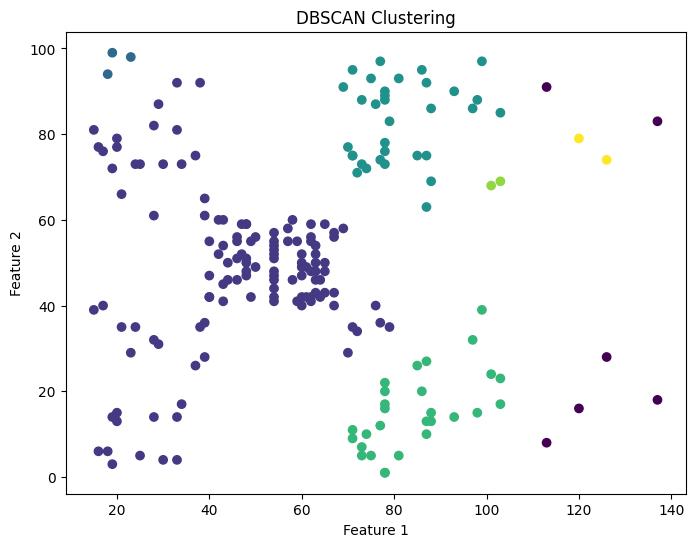

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    cd[:,0],
    cd[:,1],
    c=label,
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()